In [1]:
from jqdata import *
from jqlib.technical_analysis import *
from jqfactor import get_factor_values
from jqfactor import winsorize_med
from jqfactor import standardlize
from jqfactor import neutralize
import datetime
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels import regression
from six import StringIO
#导入pca
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.grid_search import GridSearchCV
from sklearn import metrics
from tqdm import tqdm
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
#获取指定周期的日期列表 'W、M、Q'
def get_period_date(peroid,start_date, end_date):
    #设定转换周期period_type  转换为周是'W',月'M',季度线'Q',五分钟'5min',12天'12D'
    stock_data = get_price('000001.XSHE',start_date,end_date,'daily',fields=['close'])
    stock_data['date']=stock_data.index
    period_stock_data=stock_data.resample(peroid,how='last')
    period_stock_data = period_stock_data.set_index('date').dropna()
    date=period_stock_data.index
    pydate_array = date.to_pydatetime()
    date_only_array = np.vectorize(lambda s: s.strftime('%Y-%m-%d'))(pydate_array )
    date_only_series = pd.Series(date_only_array)
    start_date = datetime.datetime.strptime(start_date, "%Y-%m-%d")
    start_date=start_date-datetime.timedelta(days=1)
    start_date = start_date.strftime("%Y-%m-%d")
    date_list=date_only_series.values.tolist()
    date_list.insert(0,start_date)
    return date_list
peroid = 'W'
start_date = '2009-01-01'
end_date = '2024-01-01'
DAY = get_period_date(peroid,start_date, end_date)
print(len(DAY))

/opt/conda/lib/python3.6/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/grid_search.py:42: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. This module will be removed in 0.20.
  DeprecationWarning)


767


In [2]:
#去除上市距beginDate不足3个月的股票
def delect_stop(stocks,beginDate,n=30*3):
    stockList=[]
    beginDate = datetime.datetime.strptime(beginDate, "%Y-%m-%d")
    for stock in stocks:
        start_date=get_security_info(stock).start_date
        if start_date<(beginDate-datetime.timedelta(days=n)).date():
            stockList.append(stock)
    return stockList
#获取股票池
def get_stock(stockPool,begin_date):
    if stockPool=='HS300':
        stockList=get_index_stocks('000300.XSHG',begin_date)
    elif stockPool=='ZZ500':
        stockList=get_index_stocks('399905.XSHE',begin_date)
    elif stockPool=='ZZ800':
        stockList=get_index_stocks('399906.XSHE',begin_date)   
    elif stockPool=='CYBZ':
        stockList=get_index_stocks('399006.XSHE',begin_date)
    elif stockPool=='ZXBZ':
        stockList=get_index_stocks('399005.XSHE',begin_date)
    elif stockPool=='A':
        stockList=get_index_stocks('000002.XSHG',begin_date)+get_index_stocks('399107.XSHE',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('68', '4', '8'))]
    elif stockPool=='AA':
        stockList=get_index_stocks('000985.XSHG',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('3', '68', '4', '8'))]
    elif stockPool=='small':
        stockList=get_index_stocks('399101.XSHE',begin_date)
        stockList = [stock for stock in stockList if not stock.startswith(('68', '4', '8'))]
    elif stockPool=='small_25':
        initial_list=get_index_stocks('000002.XSHG',begin_date)+get_index_stocks('399107.XSHE',begin_date)
        stockList = list(get_fundamentals(
        query(valuation.code,valuation.market_cap).filter(
            valuation.code.in_(initial_list),
            valuation.market_cap < 25
        ).order_by(
            valuation.circulating_market_cap.asc()
        )).code)[:50]
    
    #剔除ST股
    st_data=get_extras('is_st',stockList, count = 1,end_date=begin_date)
    stockList = [stock for stock in stockList if not st_data[stock][0]]
    #剔除停牌、新股及退市股票
    stockList=delect_stop(stockList,begin_date)
    return stockList
#获取时间为date的全部因子数据
def get_factor_data(securities_list,date,jqfactors_list):
    factor_data = get_factor_values(securities=securities_list, \
                                    factors=jqfactors_list, \
                                    count=1, \
                                    end_date=date)
    df_jq_factor=pd.DataFrame(index=securities_list)
    for i in factor_data.keys():
        df_jq_factor[i]=factor_data[i].iloc[0,:]
    return df_jq_factor
dateList = get_period_date(peroid,start_date, end_date)
print(len(dateList))

767


In [3]:
jqfactors_list= [
    'Price1Y', 
    'total_profit_to_cost_ratio', 
    'VOL120',
    'ARBR', 
    'SGAI', 
    'net_profit_to_total_operate_revenue_ttm', 
    'retained_profit_per_share',
    'price_no_fq', 
    'total_profit_to_cost_ratio', 
    'inventory_turnover_rate',
    'debt_to_assets', 
    'operating_cost_to_operating_revenue_ratio', 
    'DAVOL20', 
    'price_no_fq', 
    'sales_growth',
    'TVSTD6', 
    'cashflow_per_share_ttm', 
    'sharpe_ratio_120', 
    'non_operating_net_profit_ttm'
]

train_data=pd.DataFrame()
train_length = 15*12*4
for date in tqdm(dateList[:train_length]):
    try:
        stockList=get_stock('small_25',date)
        print(len(stockList))
        factor_solve_data = get_factor_data(stockList,date,jqfactors_list)
        data_close=get_price(stockList,date,dateList[dateList.index(date)+1],'1d','close')['close']
        factor_solve_data['pchg']=data_close.iloc[-1]/data_close.iloc[1]-1
        factor_solve_data['date']=date
        if train_data.empty:
            train_data=factor_solve_data
        else:
            train_data=train_data.append(factor_solve_data)
    except:
        pass
            
train_data.to_csv(r'train_baseline_2.0_1.csv')
print(len(train_data))  

  0%|          | 0/720 [00:00<?, ?it/s]

41


  0%|          | 1/720 [00:01<13:33,  1.13s/it]

41


  0%|          | 2/720 [00:02<13:01,  1.09s/it]

...

42


100%|█████████▉| 719/720 [17:22<00:02,  2.63s/it]

42


100%|██████████| 720/720 [17:23<00:00,  2.29s/it]


30866


In [4]:
train_data=pd.DataFrame()
for date in tqdm(dateList[train_length:-1]):
    try:
        stockList=get_stock('small_25',date)
        factor_solve_data = get_factor_data(stockList,date,jqfactors_list)
        data_close=get_price(stockList,date,dateList[dateList.index(date)+1],'1d','close')['close']
        factor_solve_data['pchg']=data_close.iloc[-1]/data_close.iloc[1]-1
        factor_solve_data['date']=date
        if train_data.empty:
            train_data=factor_solve_data
        else:
            train_data=train_data.append(factor_solve_data)
    except:
        pass
            
train_data.to_csv(r'test_baseline_2.0_1.csv')
print(len(train_data))

100%|██████████| 46/46 [01:19<00:00,  1.71s/it]

1696


In [13]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
import pickle
from xgboost import XGBClassifier ,XGBRegressor
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
import pickle
from xgboost import XGBClassifier ,XGBRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, recall_score, precision_score
from sklearn.metrics import precision_recall_curve, auc
import lightgbm as lgb 
import xgboost as xgb 
import joblib  
from sklearn.linear_model import Ridge,BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score

jqfactors_list= [
    'Price1Y', 
    'total_profit_to_cost_ratio', 
    'VOL120',
    'ARBR', 
    'SGAI', 
    'net_profit_to_total_operate_revenue_ttm', 
    'retained_profit_per_share',
    'price_no_fq', 
    'total_profit_to_cost_ratio', 
    'inventory_turnover_rate',
    'debt_to_assets', 
    'operating_cost_to_operating_revenue_ratio', 
    'DAVOL20', 
    'price_no_fq', 
    'sales_growth',
    'TVSTD6', 
    'cashflow_per_share_ttm', 
    'sharpe_ratio_120', 
    'non_operating_net_profit_ttm'
]
# X_train = pd.read_csv('train_baseline_2.0_1.csv').fillna(0)
# X_test = pd.read_csv('test_baseline_2.0_1.csv').fillna(0)
X_train = pd.read_csv('train_baseline_2.0_1.csv')
X_test = pd.read_csv('test_baseline_2.0_1.csv')
columns_to_fill = [col for col in jqfactors_list if col in X_train.columns]
df_filled_train = X_train.copy()
for column in columns_to_fill:
    df_filled_train[column] = X_train.groupby('date')[column].transform(lambda x: x.fillna(x.median()))
X_train = df_filled_train.dropna()

df_filled_test = X_test.copy()
for column in columns_to_fill:
    df_filled_test[column] = X_test.groupby('date')[column].transform(lambda x: x.fillna(x.median()))
X_test = df_filled_test.dropna()



y_train = X_train['pchg']
y_test =X_test['pchg']


In [14]:

jqfactors_list1=[
                'ARBR', #情绪类因子 ARBR
                'SGAI', #质量类因子 销售管理费用指数
                'net_profit_to_total_operate_revenue_ttm', #质量类因子 净利润与营业总收入之比
                'retained_profit_per_share' #每股指标因子 每股未分配利润
            ]
X_train1 = X_train[jqfactors_list1]
X_test1 = X_test[jqfactors_list1]

Bridge1 = BayesianRidge()
Bridge1.fit(X_train1,y_train)
print(Bridge1.coef_)

bridge_manual_predictions1 = np.dot(X_test1, Bridge1.coef_)
bridge_manual_mse = mean_squared_error(y_test, bridge_manual_predictions1)
bridge_manual_r2 = r2_score(y_test, bridge_manual_predictions1)

print("\nBayesian Ridge Regression (Manual Prediction):")
print("Mean Squared Error:", bridge_manual_mse)
print("R^2 Score:", bridge_manual_r2)

[-3.894481386287797e-19 6.051549381361553e-05 -0.00013489470173496827
 -0.0006228721291235472]

Bayesian Ridge Regression (Manual Prediction):
Mean Squared Error: 0.0028980287683567185
R^2 Score: -0.0018429275272147105


In [15]:
jqfactors_list2=            [
                'Price1Y', #动量类因子 当前股价除以过去一年股价均值再减1
                'total_profit_to_cost_ratio', #质量类因子 成本费用利润率
                'VOL120' #情绪类因子 120日平均换手率
            ]
X_train2 = X_train[jqfactors_list2]
X_test2 = X_test[jqfactors_list2]

Bridge2 = BayesianRidge()
Bridge2.fit(X_train2,y_train)
print(Bridge2.coef_)


bridge_manual_predictions2 = np.dot(X_test2, Bridge2.coef_)
bridge_manual_mse = mean_squared_error(y_test, bridge_manual_predictions2)
bridge_manual_r2 = r2_score(y_test, bridge_manual_predictions2)

print("\nBayesian Ridge Regression (Manual Prediction):")
print("Mean Squared Error:", bridge_manual_mse)
print("R^2 Score:", bridge_manual_r2)

[-0.007686604605324844 -0.001064082235156668 -0.0006372186835828526]

Bayesian Ridge Regression (Manual Prediction):
Mean Squared Error: 0.0028843045859191833
R^2 Score: 0.0029014957377532236


In [16]:
jqfactors_list3=                       [
                'price_no_fq', #技术指标因子 不复权价格因子
                'total_profit_to_cost_ratio', #质量类因子 成本费用利润率
                'inventory_turnover_rate' #质量类因子 存货周转率
            ]
X_train3 = X_train[jqfactors_list3]
X_test3 = X_test[jqfactors_list3]

Bridge3 = BayesianRidge()
Bridge3.fit(X_train3,y_train)
print(Bridge3.coef_)


bridge_manual_predictions3 = np.dot(X_test3, Bridge3.coef_)
bridge_manual_mse = mean_squared_error(y_test, bridge_manual_predictions3)
bridge_manual_r2 = r2_score(y_test, bridge_manual_predictions3)

print("\nBayesian Ridge Regression (Manual Prediction):")
print("Mean Squared Error:", bridge_manual_mse)
print("R^2 Score:", bridge_manual_r2)

[-0.00022239096483198066 -0.0003400190412564607 -1.2360751761544718e-08]

Bayesian Ridge Regression (Manual Prediction):
Mean Squared Error: 0.0029390157991324747
R^2 Score: -0.016012064614944865


In [17]:
jqfactors_list4=                       [
                'debt_to_assets', #风格因子 资产负债率
                'operating_cost_to_operating_revenue_ratio', #质量类因子 销售成本率
                'DAVOL20', #情绪类因子 20日平均换手率与120日平均换手率之比
                'price_no_fq', #技术指标因子 不复权价格因子
                'sales_growth' #风格因子 5年营业收入增长率
            ]
X_train4 = X_train[jqfactors_list4]
X_test4 = X_test[jqfactors_list4]

Bridge4 = BayesianRidge()
Bridge4.fit(X_train4,y_train)
print(Bridge4.coef_)


bridge_manual_predictions4 = np.dot(X_test4, Bridge4.coef_)
bridge_manual_mse = mean_squared_error(y_test, bridge_manual_predictions4)
bridge_manual_r2 = r2_score(y_test, bridge_manual_predictions4)

print("\nBayesian Ridge Regression (Manual Prediction):")
print("Mean Squared Error:", bridge_manual_mse)
print("R^2 Score:", bridge_manual_r2)

[-0.0013461722141220884 0.001285717224773847 -0.003021350121015241
 -0.00023334854089909846 0.0002343967416749908]

Bayesian Ridge Regression (Manual Prediction):
Mean Squared Error: 0.002966837818539928
R^2 Score: -0.02563008279241341


In [18]:
jqfactors_list5=                      [
                'TVSTD6', #情绪类因子 6日成交金额的标准差
                'cashflow_per_share_ttm', #每股指标因子 每股现金流量净额
                'sharpe_ratio_120', #风险类因子 120日夏普率
                'non_operating_net_profit_ttm' #基础科目及衍生类因子 营业外收支净额TTM
            ]
X_train5 = X_train[jqfactors_list5]
X_test5 = X_test[jqfactors_list5]

Bridge5 = BayesianRidge()
Bridge5.fit(X_train5,y_train)
print(Bridge5.coef_)


bridge_manual_predictions5 = np.dot(X_test5, Bridge5.coef_)
bridge_manual_mse = mean_squared_error(y_test, bridge_manual_predictions5)
bridge_manual_r2 = r2_score(y_test, bridge_manual_predictions5)

print("\nBayesian Ridge Regression (Manual Prediction):")
print("Mean Squared Error:", bridge_manual_mse)
print("R^2 Score:", bridge_manual_r2)

[-6.694922635779981e-11 -0.00016142377647805555 -0.0005529870175398643
 9.167393894186556e-12]

Bayesian Ridge Regression (Manual Prediction):
Mean Squared Error: 0.0028554832983580043
R^2 Score: 0.01286495897893003


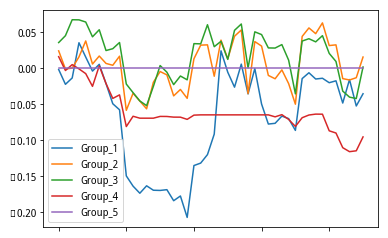

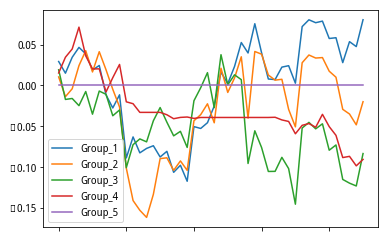

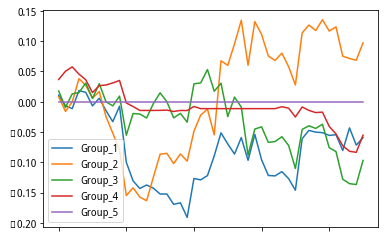

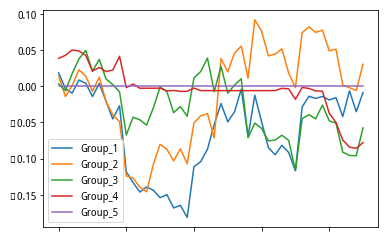

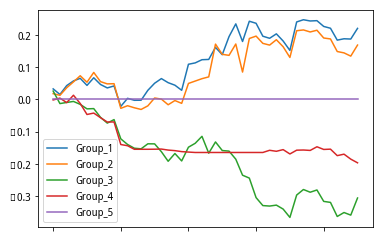

In [19]:

def calculate_layered_returns(result_df, returns_df, num_layers=20):
    backtest_results = pd.DataFrame(columns=[f'Group_{i}' for i in range(1, num_layers + 1)])

    for date in result_df.index:
        # 获取当天的因子值和收益率
        factors = result_df.loc[date]
        returns = returns_df.loc[date]

        # 合并因子值和收益率到一个DataFrame中
        combined_data = pd.DataFrame({'Factor': factors, 'Returns': returns})

        # 按因子值排序
        combined_data = combined_data.sort_values(by='Factor', ascending=False)

        # 分成num_layers组，每组数量相等
        group_size = len(combined_data) // num_layers

        groups = []
        for i in range(num_layers):
            start_idx = i * group_size
            end_idx = (i + 1) * group_size
            group = combined_data.iloc[start_idx:end_idx]
            groups.append(group)

        # 计算每个组的累积收益率
        group_returns = []
        for group in groups:
            group_return = group['Returns'].sum()
            group_returns.append(group_return)

        # 将每个组的累积收益率添加到结果DataFrame中
        backtest_results.loc[date] = [i/group_size for i in group_returns]

    return backtest_results
predictions = [bridge_manual_predictions1,bridge_manual_predictions2,bridge_manual_predictions3,bridge_manual_predictions4,bridge_manual_predictions5]
X_test.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
for i in range(5):
    y_pred_proba =predictions[i]
    X_test['factor'] = y_pred_proba
    factor = X_test.set_index(['id', 'date'])['factor']
    factor = factor.unstack(level='id')
    ret = X_test.set_index(['id', 'date'])['pchg']
    ret = ret.unstack(level='id')
    backtest_results = calculate_layered_returns(factor, ret, num_layers=5)
    backtest_results.cumsum().plot()

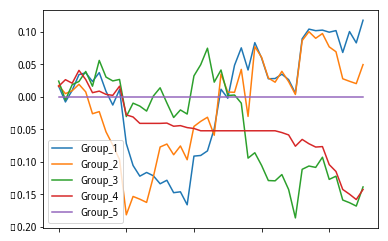

In [20]:
X_test.rename(columns={'Unnamed: 0': 'id'}, inplace=True)
y_pred_proba=0
for i in range(5):
    y_pred_proba +=predictions[i]
    
X_test['factor'] = y_pred_proba
factor = X_test.set_index(['id', 'date'])['factor']
factor = factor.unstack(level='id')
ret = X_test.set_index(['id', 'date'])['pchg']
ret = ret.unstack(level='id')
backtest_results = calculate_layered_returns(factor, ret, num_layers=5)
backtest_results.cumsum().plot()